# Dataset Zonas Claves Del Campo

En este notebook analizaremos el dataset de Soccernet y lo modificaremos para crear un dataset de puntos claves.

In [3]:
#Descargamos el dataset de SoccerNet 
from utils.config import PITCH_KEYPOINTS_DATA
from SoccerNet.Downloader import SoccerNetDownloader as SNdl
from utils.segmentation import draw_field_lines

%reload_ext autoreload
%autoreload 2


In [ ]:
#soccerNetDownloader = SNdl(LocalDirectory=PITCH_KEYPOINTS_DATA)
#soccerNetDownloader.downloadDataTask(task="calibration-2023", split=["train","valid","test"])

El dataset de Soccernet está compuesto por tres conjuntos : entrenamiento, validacion y prueba.


Cada conjunto tiene las imagenes y un archivo en formato JSON por cada imagen con las anotaciones.

In [4]:
import os 
import pandas as pd

soccernet_path = os.path.join(PITCH_KEYPOINTS_DATA,"soccernet")

sets_names = os.listdir(soccernet_path)

data = []
for set_name in sets_names:

    set_path = os.path.join(soccernet_path,set_name)
    imgs = len(os.listdir(set_path))/2 #Cada imagen tiene un json con las anotaciones, por lo que dividimos entre 2 para obtener el numero de imagenes

    data.append([set_name,int(imgs)])

df = pd.DataFrame(data,columns=["Conjunto","Imágenes"])
df



,Conjunto,Imágenes
0,valid,3212
1,test,3141
2,train,16463


El dataset de Soccernet es un conjunto de datos de segmentación por lo que las anotaciones hacen referencia a las lineas enteras que aparecen en cada imagen.

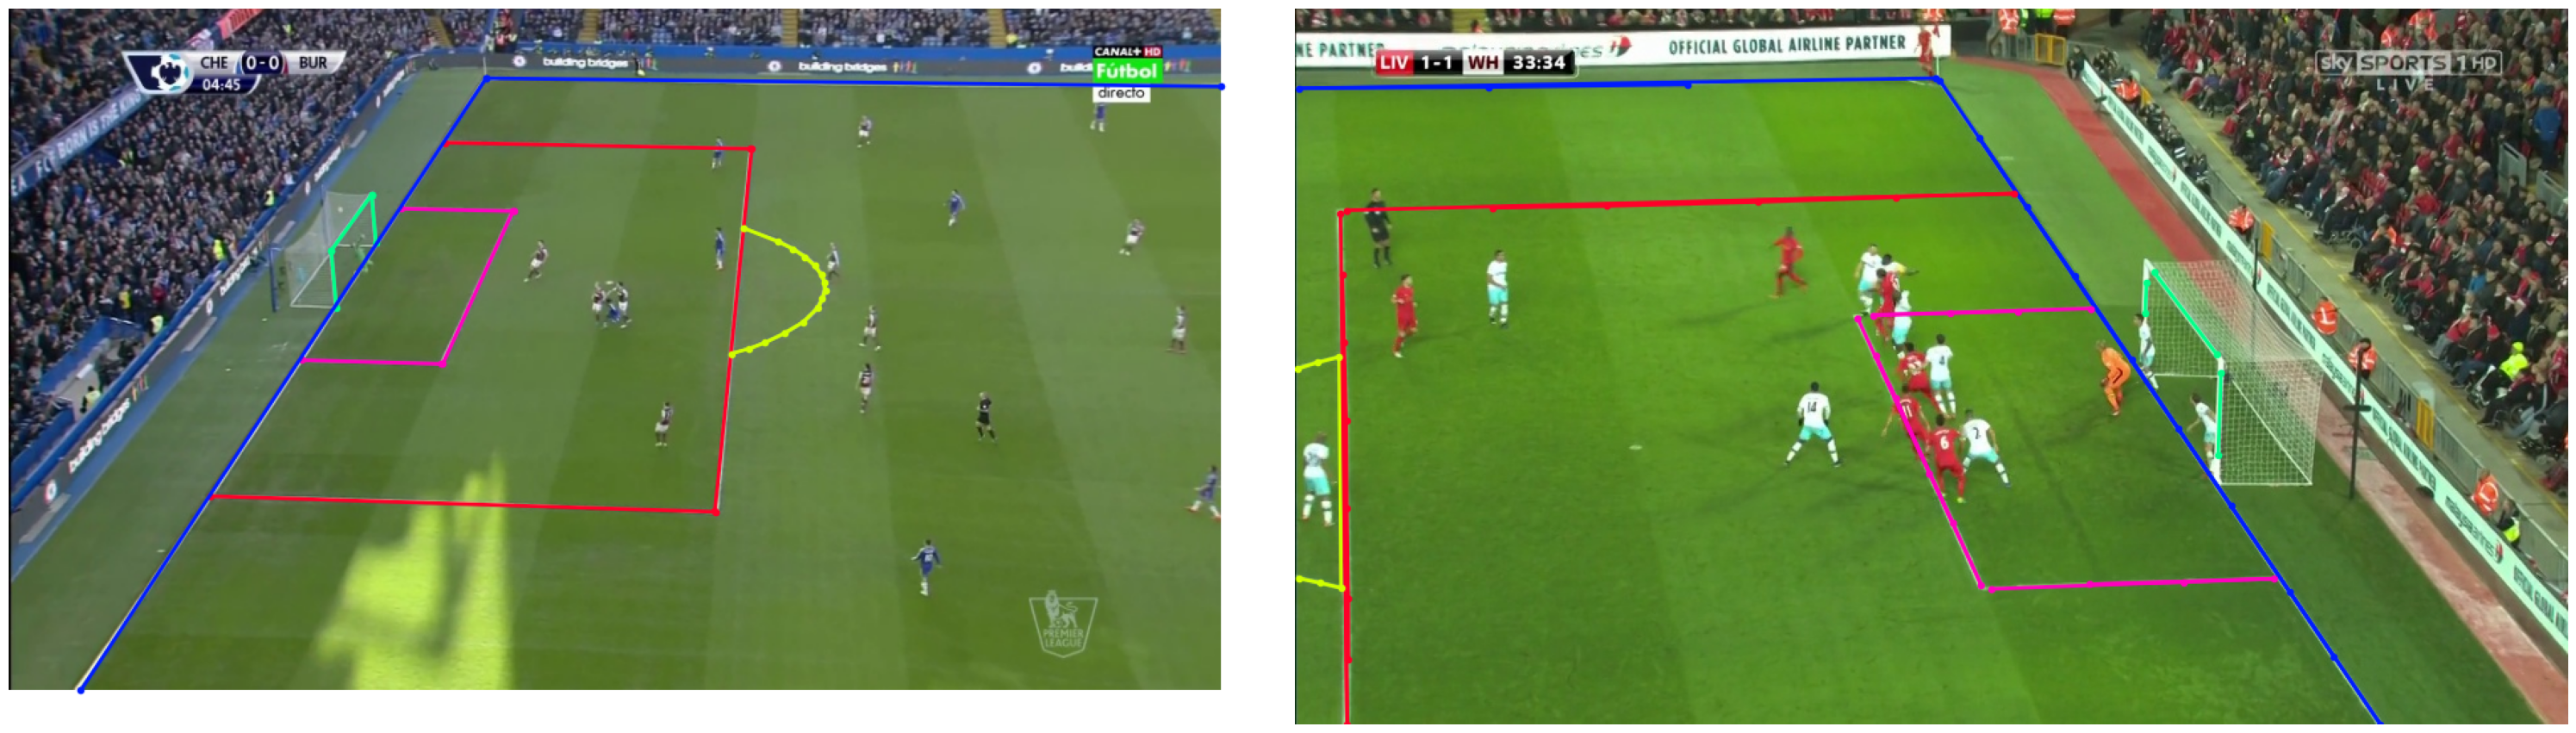

In [5]:
from utils.image_tools import display_image
from utils.image_tools import display_images
import os

img_sample= [os.path.join(soccernet_path,"train","00001.jpg"),os.path.join(soccernet_path,"train","03066.jpg")]
label_sample = [img.replace(".jpg",".json") for img in img_sample]

imgs = [draw_field_lines(image_path=img,json_source=label) for img,label in zip(img_sample,label_sample)]

display_images(imgs,rows=1,cols=2)


# Metodología de Localización: Sistema de 57 Puntos Clave

Para lograr una localización precisa de las entidades dentro del terreno de juego, hemos desarrollado un sistema de referencia basado en **57 puntos clave (keypoints)**. 

Estos puntos actúan como referencia que permite transformar una imagen bidimensional en un modelo espacial con dimensiones reales.

La obtención de estos 57 puntos se rige por los siguientes cuatro pilares:



### 1. Intersecciones Geométricas Estructurales (**Puntos Rojos y Azules**)
La base de nuestros puntos claves se construye a partir de los segmentos de línea del terreno de juego proporcionados por el dataset de **SoccerNet**.

* **Cálculo de Vértices**: Utilizando el script `intersections.py`, identificamos los puntos donde dos líneas se cruzan físicamente (por ejemplo, el cruce de las líneas de banda con las de fondo o las esquinas de las áreas).
* **Ajuste Lineal**: El código emplea funciones de ajuste polinómico (`polyfit`) para modelar las líneas incluso ante ruidos en la detección. 
* **Precisión Matemática**: Esto asegura que el punto de cruce calculado sea matemáticamente exacto según la tendencia de los píxeles, definiendo así los puntos estructurales primarios.

### 2. Rectas Tangenciales en Curvas (**Puntos Morados**)
Para los elementos circulares donde no existen vértices naturales (círculo central y arcos de área), el módulo `ellipse.py` gestiona la geometría de las elipses proyectadas.

* **Ajuste de Elipses**: Mediante el algoritmo de mínimos cuadrados implementado en la clase `LsqEllipse`, ajustamos una curva a los puntos detectados del círculo central y los arcos de área.
* **Puntos Tangenciales**: Calculamos puntos específicos donde una línea teórica "toca" la curva (tangencia). 


### 3. Homografías y Proyecciones (**Puntos Verdes y Negros**)
En situaciones donde ciertos puntos no son visibles debido al encuadre de la cámara o a oclusiones, aplicamos técnicas de geometría proyectiva para inferir su ubicación.

* **Inferencia de Posición**: Utilizando la posición de los puntos previamente calculados y conociendo la geometría proyectiva de la cámara, somos capaces de "proyectar" la ubicación exacta de estos puntos adicionales.


### 4. Precisión Matemática mediante Medidas Oficiales (FIFA)
Finalmente, todo el sistema se valida y escala utilizando el módulo `soccerpitch.py`, que actúa como nuestra referencia de verdad absoluta.

* **Validación de Coordenadas**: Este componente contiene las medidas oficiales (longitud de 105m, ancho de 68m, radio de 9.15m, etc.) para validar la precisión de los 57 puntos extraídos.
* **Mapeo Top-Down**: Al contrastar los píxeles con estas medidas fijas, transformamos la vista de la cámara en una representación cenital (*top-down*) exacta. 
* **Robustez ante la Perspectiva**: Esto garantiza que el sistema sea robusto frente a cambios de perspectiva o distorsión de lente, entendiendo que las distancias matemáticas en el campo se mantienen constantes.



<p align="center">
  <img src="/home/adrian/IA-Futbol/images/pitch_pattern.jpg" width="800" alt="Pitch Pattern Keypoints">
</p>

Calcularemos estos puntos y modificaremos el dataset en `scripts/pitch_dataset.py`

# Análisis del Dataset
Una vez calculados los puntos claves de cada imagen obtenemos un nuevo dataset que interesa analizar

{0: (0.0, 0.0, 0), 1: (0.0, 0.0, 0), 2: (0.0, 0.0, 0), 3: (0.0, 0.0, 0), 4: (0.0, 0.0, 0), 5: (0.0, 0.0, 0), 6: (0.0, 0.0, 0), 7: (0.0, 0.0, 0), 8: (0.0, 0.0, 0), 9: (0.0, 0.0, 0), 10: (0.0, 0.0, 0), 11: (0.0, 0.0, 0), 12: (0.0, 0.0, 0), 13: (0.0, 0.0, 0), 14: (0.0, 0.0, 0), 15: (0.275776, 0.089539, 2), 16: (0.0, 0.0, 0), 17: (0.875941, 0.117625, 2), 18: (0.0, 0.0, 0), 19: (0.0, 0.0, 0), 20: (0.0, 0.0, 0), 21: (0.0, 0.0, 0), 22: (0.0, 0.0, 0), 23: (0.0, 0.0, 0), 24: (0.0, 0.0, 0), 25: (0.0, 0.0, 0), 26: (0.0, 0.0, 0), 27: (0.0, 0.0, 0), 28: (0.0, 0.0, 0), 29: (0.0, 0.0, 0), 30: (0.48983, 0.256431, 2), 31: (0.056825, 0.276602, 2), 32: (0.511584, 0.293292, 2), 33: (0.035516, 0.32862, 2), 34: (0.424272, 0.222347, 2), 35: (0.128888, 0.240434, 2), 36: (0.46865, 0.340928, 2), 37: (0.088218, 0.372015, 2), 38: (0.508258, 0.269838, 2), 39: (0.037608, 0.302867, 2), 40: (0.2799, 0.214895, 2), 41: (0.285603, 0.388203, 2), 42: (0.281986, 0.285717, 2), 43: (0.0, 0.0, 0), 44: (0.0, 0.0, 0), 45: (0.0,

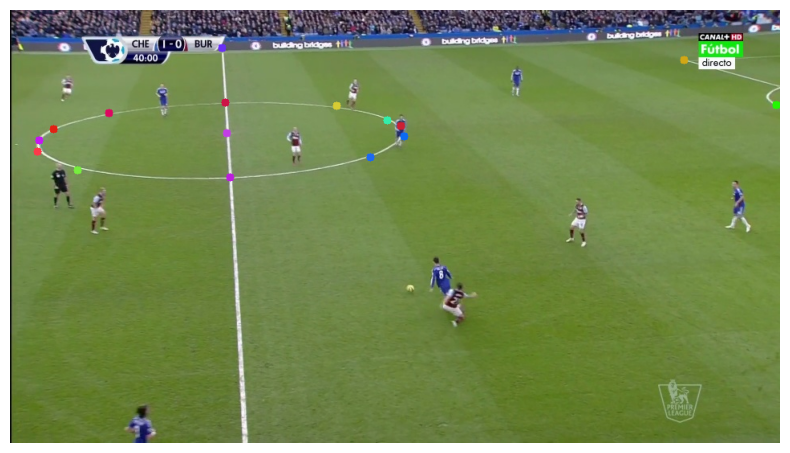

In [7]:
from utils.config import PITCH_KEYPOINTS_DATA
from utils.image_tools import display_image,annotate_yolo_pose
%reload_ext autoreload
%autoreload 2

image = os.path.join(PITCH_KEYPOINTS_DATA, "train","images","00020.jpg")
label = os.path.join(PITCH_KEYPOINTS_DATA, "train","labels","00020.txt")

def read_label(label_path):
    """
    Lee una etiqueta de formato YOLO Pose y devuelve un diccionario con los puntos clave y sus coordenadas.
    """
    puntos = {}
    
    if not os.path.exists(label_path):
        raise FileNotFoundError(f"No se encontró el archivo en: {label_path}")

    with open(label_path, 'r', encoding='utf-8') as f:

        yolo_line = f.readline().strip().split()

        class_id = 0
        for i in range(5, len(yolo_line), 3):
            puntos[class_id] = (float(yolo_line[i]), float(yolo_line[i+1]), int(yolo_line[i+2]))
            class_id += 1
    
    return puntos

image = annotate_yolo_pose(image, read_label(label))
display_image(image,figsize=(8,6))

{0: (0.276126, 0.407734, 2), 1: (0.311278, 0.322629, 2), 2: (0.27989, 0.490034, 2), 3: (0.314665, 0.397525, 2), 4: (0.370115, 0.578769, 2), 5: (0.43075, 0.347782, 2), 6: (0.248301, 0.574066, 2), 7: (0.335372, 0.342442, 2), 8: (0.605815, 0.80988, 2), 9: (0.634469, 0.252573, 2), 10: (0.170793, 0.78025, 2), 11: (0.373003, 0.242335, 2), 12: (0.0, 0.0, 0), 13: (0.408697, 0.147384, 2), 14: (0.0, 0.0, 0), 15: (0.0, 0.0, 0), 16: (0.0, 0.0, 0), 17: (0.0, 0.0, 0), 18: (0.0, 0.0, 0), 19: (0.0, 0.0, 0), 20: (0.0, 0.0, 0), 21: (0.0, 0.0, 0), 22: (0.0, 0.0, 0), 23: (0.0, 0.0, 0), 24: (0.0, 0.0, 0), 25: (0.0, 0.0, 0), 26: (0.0, 0.0, 0), 27: (0.0, 0.0, 0), 28: (0.0, 0.0, 0), 29: (0.0, 0.0, 0), 30: (0.0, 0.0, 0), 31: (0.0, 0.0, 0), 32: (0.0, 0.0, 0), 33: (0.0, 0.0, 0), 34: (0.0, 0.0, 0), 35: (0.0, 0.0, 0), 36: (0.0, 0.0, 0), 37: (0.0, 0.0, 0), 38: (0.0, 0.0, 0), 39: (0.0, 0.0, 0), 40: (0.0, 0.0, 0), 41: (0.0, 0.0, 0), 42: (0.0, 0.0, 0), 43: (0.698342, 0.465153, 2), 44: (0.618381, 0.565481, 2), 45: (0.6

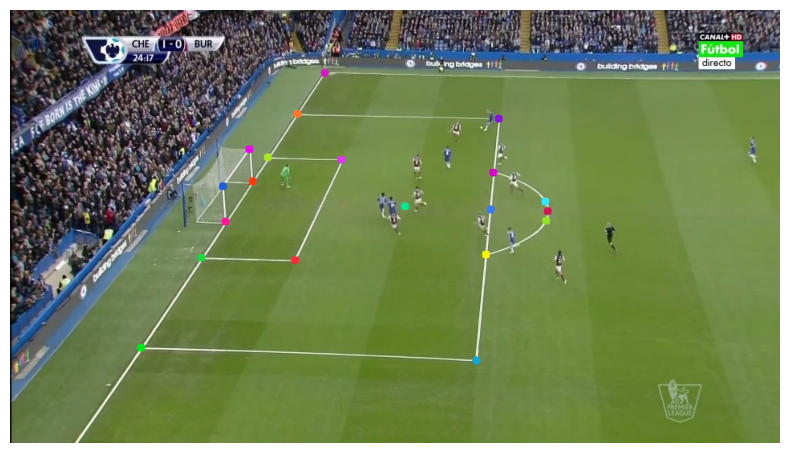

In [55]:
image = os.path.join(PITCH_KEYPOINTS_DATA, "train","images","00011.jpg")
label = os.path.join(PITCH_KEYPOINTS_DATA, "train","labels","00011.txt")
image = annotate_yolo_pose(image, read_label(label))
display_image(image,figsize=(8,6))

Procedemos entonces a realizar un muestreo y como se distribuyen los datos 

In [56]:
from collections import defaultdict
train_path = os.path.join(PITCH_KEYPOINTS_DATA, "train","labels")
test_path = os.path.join(PITCH_KEYPOINTS_DATA, "test","labels")
val_path = os.path.join(PITCH_KEYPOINTS_DATA, "val","labels")

def count_labels(label_dir):
    """
    Dado un subconjunto de datos (train, test o val), cuenta el número de instancias de cada tipo de punto clave.
    """

    count = defaultdict(int) #defecto 0
    
    for filename in os.listdir(label_dir):
        labels = read_label(os.path.join(label_dir, filename))

        for id, data in labels.items():

            (x,y,v) = data

            if v == 2: # Solo contamos los puntos visibles
                count[id] +=1


    return count

count_train = count_labels(train_path)

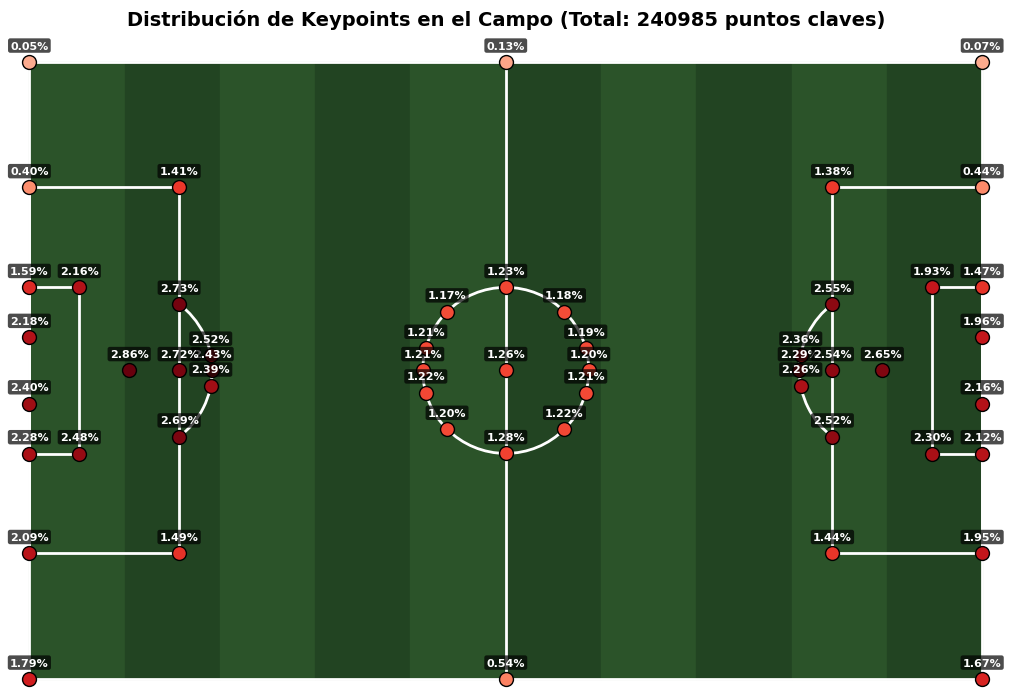

In [73]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
from utils.pitch import draw_pitch
from pitch_keypoints.ellipse import INTERSECTON_TO_PITCH_POINTS, PITCH_POINTS

def plot_results(counts):

    total = sum(counts.values())
    fig, ax = draw_pitch(figsize=(10, 7))

    min_c = min(counts.values())
    max_c = max(counts.values())
    cmap = plt.cm.Reds
    
    for id, cls in INTERSECTON_TO_PITCH_POINTS.items():

        cls = INTERSECTON_TO_PITCH_POINTS[id] 

        if  cls != "L_GOAL_TL_POST" and cls != "L_GOAL_TR_POST" and cls !="R_GOAL_TL_POST" and cls != "R_GOAL_TR_POST":

            x,y,_ = PITCH_POINTS[cls]

            def get_red(count_val):
                
                norm_val = (count_val - min_c) / (max_c - min_c)
                shifted_val = 0.3 + (norm_val * 0.7)
                return cmap(shifted_val)
            
            color = get_red(counts[id])

            ax.plot(x, y, "o", color=color, markersize=10, zorder=3, markeredgecolor='black')
            # Etiqueta con fondo oscuro
            ax.text(x, y + 1.8, 
                    f"{counts[id]/total * 100:.2f}%", 
                    color='white', 
                    fontsize=8, 
                    ha='center', 
                    va='center', 
                    zorder=4, 
                    fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.7, boxstyle='round,pad=0.2', edgecolor='none'))


    plt.title(f"Distribución de Keypoints en el Campo (Total: {int(total)} puntos claves)", fontsize=14, pad=20, fontweight='bold')
    plt.show() 

plot_results(count_train)